# Alfven wave propagation test


In [1]:
# some preliminary settings and functions

import sys
sys.path.append("/home/aunai/build_phare")
sys.path.append("/home/aunai/PHARE/pyphare/")
import os
import numpy as np
import pyphare
from pyphare.pharesee.hierarchy import hierarchy_from
import matplotlib.pyplot as plt
from pyphare.pharesee.run import Run
from pyphare.pharesee.hierarchy import compute_hier_from, finest_field
from IPython.display import display, Markdown
%matplotlib notebook

In [5]:
path2runs = "/DATA/phare/pharebook_data/tests/alfven_wave/"

In [8]:
    display(Markdown(path2runs+"README.md"))

# Aflven wave tests

runs 001 and 002 have been performed with 10 substeps per level time step.
in MultiPhysicsIntegrator::getMaxFinerLevelDt

```cpp
            return coarseDt / (ratio.max() * ratio.max()) /** 0.4*/ ;
```

run003 is ran with 4 substep only

- run001 : alfven wave with no refinement
- run002 : aflven wave with fixed mesh refinement
- run003 : no refinement alfven wave with only 4 substep per level step
- run004 : alfven wave with no refinement with 2 mpi processes
- run005 : is run004 with 400 cells and 10 mpi processes
- run006 : run005 with larger refined domain
- run007 : run006 with longer time
- run008 : run007 with dB =0.01
- run009 : run008 with no seed
- run010 : run009 with 0.01 and T=L=1000

  -------------------------------------
        runs before this line are deprecated

- run011 : run010 with larger L1
- run012 : run011 with new release fix to diag time stamps, Tf=80 (for test)
- run013 : run012 T=1000=L with dx=1




## Phase velocity

In [2]:
def wave(x, a0, k, phi):
    return a0*np.cos(k*x + phi)

In [3]:
def phase_speed(run_path, ampl, xmax):
    from scipy.signal import medfilt
    import os
    time = np.asarray(get_times(os.path.join(run_path,"EM_B.h5")))
    r = Run(run_path)
    phase = np.zeros_like(time)
    amplitude = np.zeros_like(time)
    wave_vec = np.zeros_like(time)
    
    for it, t in enumerate(time):
        B = r.GetB(t)
        by, xby = finest_field(B, "By")
        a, k, phi = curve_fit(wave, xby, by,p0=(ampl, 2*np.pi/xmax, 0))[0]
        phase[it] = phi
        amplitude[it] = a
        wave_vec[it]  = k
        
    vphi = medfilt(np.gradient(phase, time)/wave_vec, kernel_size=7)
    return vphi, time, phase, amplitude, wave_vec

In [159]:
vphi7, t7, phi7, a7, k7 = phase_speed("../phare_jobs/tests/alfven_wave/run007", 0.1, 120)

In [193]:
vphi8, t8, phi8, a8, k8 = phase_speed("../phare_jobs/tests/alfven_wave/run008", 0.01, 120)

In [195]:
vphi9, t9, phi9, a9, k9 = phase_speed("../phare_jobs/tests/alfven_wave/run009", 0.01, 120)

In [292]:
vphi10, t10, phi10, a10, k10 = phase_speed("../phare_jobs/tests/alfven_wave/run010", 0.01, 1000)

In [338]:
vphi11, t11, phi11, a11, k11 = phase_speed("../phare_jobs/tests/alfven_wave/run011", 0.01, 1000)

In [435]:
vphi13, t13, phi13, a13, k13 = phase_speed("/DATA/phare/pharebook_data/tests/alfven_wave/run013", 0.01, 1000)

<IPython.core.display.Javascript object>


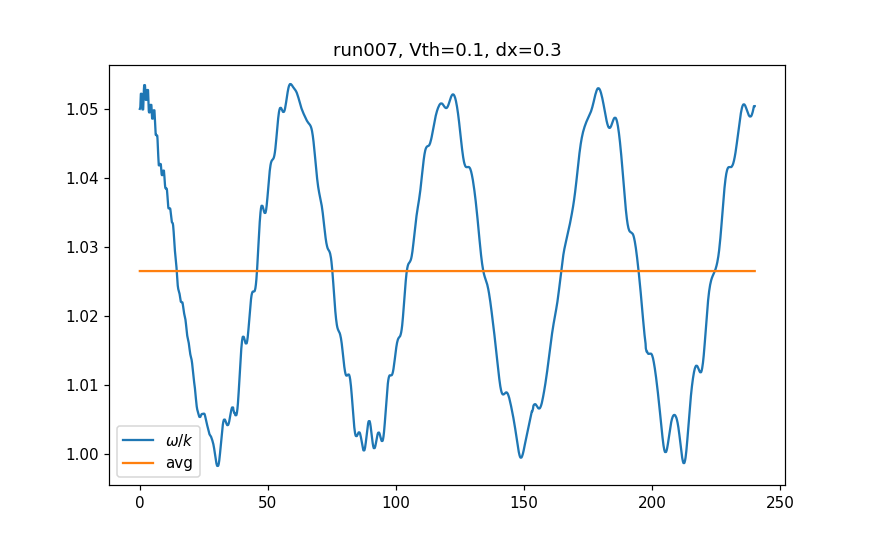

Text(0.5, 1.0, 'run007, Vth=0.1, dx=0.3')

In [189]:
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(t7, vphi7, label=r"$\omega/k$")
ax.plot(t7, np.zeros_like(t7)+np.mean(vphi7), label="avg")
ax.legend()
ax.set_title("run007, Vth=0.1, dx=0.3")

<IPython.core.display.Javascript object>


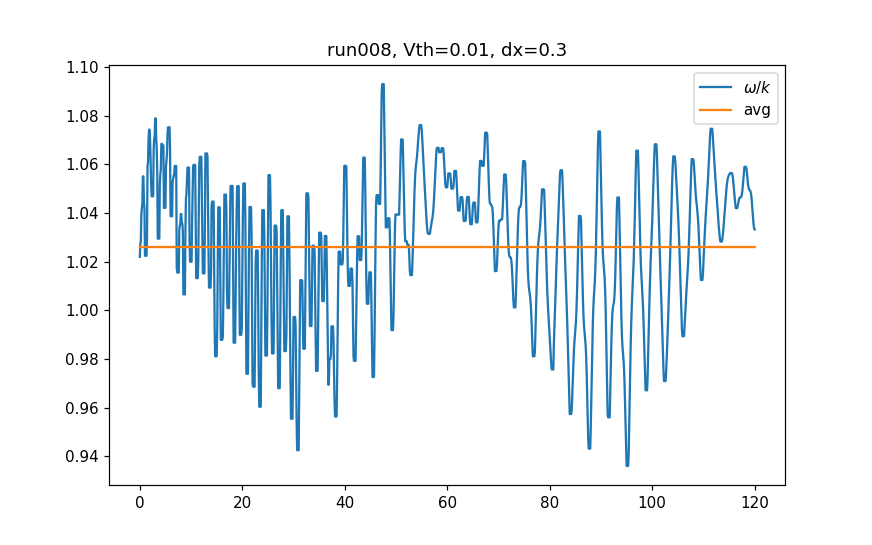

Text(0.5, 1.0, 'run008, Vth=0.01, dx=0.3')

In [194]:
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(t8, vphi8, label=r"$\omega/k$")
ax.plot(t8, np.zeros_like(t8)+np.mean(vphi8), label="avg")
ax.legend()
ax.set_title("run008, Vth=0.01, dx=0.3 (constant seed)")

<IPython.core.display.Javascript object>


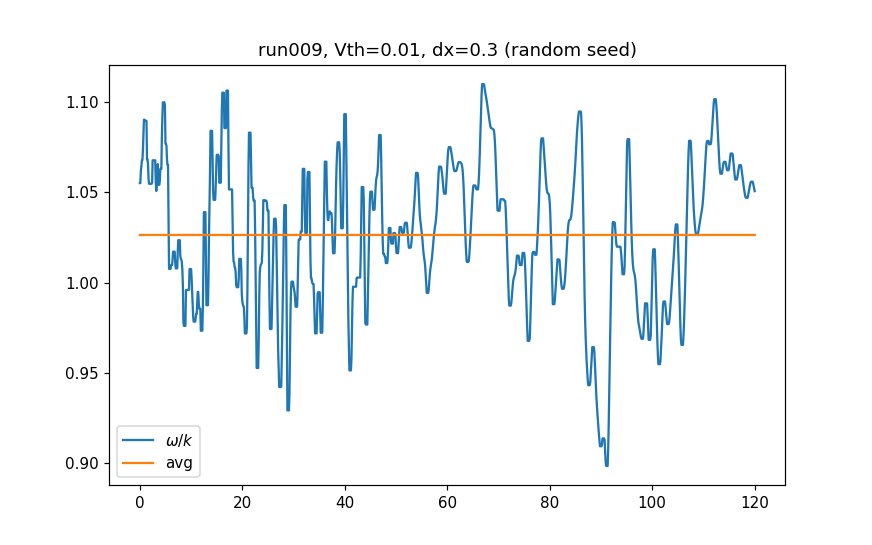

Text(0.5, 1.0, 'run009, Vth=0.01, dx=0.3 (random seed)')

In [196]:
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(t9, vphi9, label=r"$\omega/k$")
ax.plot(t9, np.zeros_like(t9)+np.mean(vphi9), label="avg")
ax.legend()
ax.set_title("run009, Vth=0.01, dx=0.3 (random seed)")

<IPython.core.display.Javascript object>


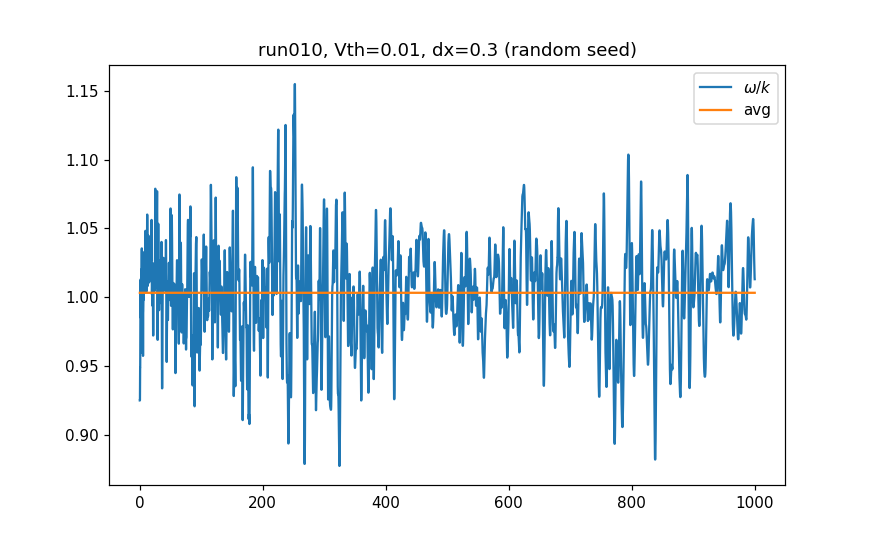

Text(0.5, 1.0, 'run010, Vth=0.01, dx=0.3 (random seed)')

In [293]:
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(t10, vphi10, label=r"$\omega/k$")
ax.plot(t10, np.zeros_like(t10)+np.mean(vphi10), label="avg")
ax.legend()
ax.set_title("run010, Vth=0.01, dx=0.3 (random seed)")

<IPython.core.display.Javascript object>


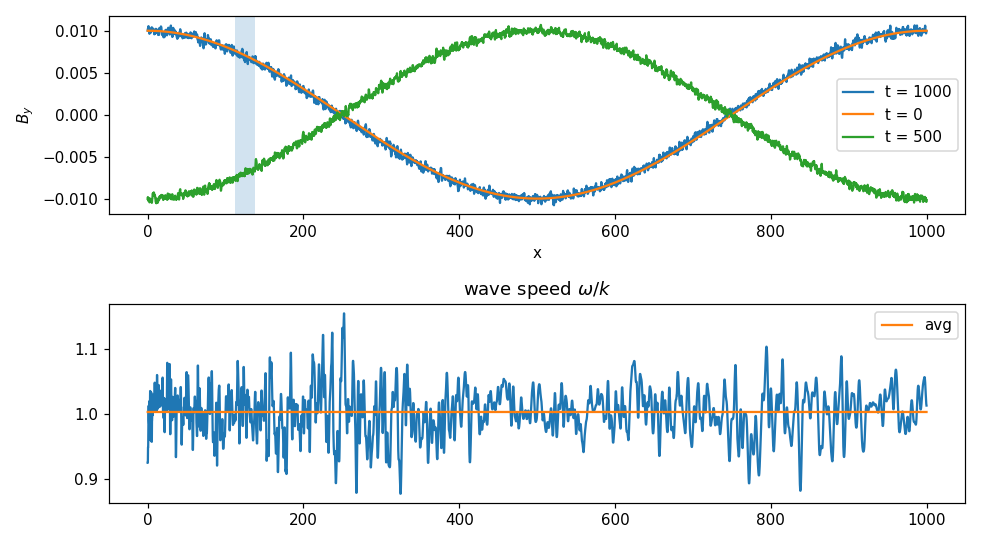

In [326]:
r10 = Run("../phare_jobs/tests/alfven_wave/run010")
t10 = get_times("../phare_jobs/tests/alfven_wave/run010/EM_B.h5")
B = r10.GetB(t10[-1])
fig,(ax1,ax2) = plt.subplots(figsize=(9,5), nrows=2)
by, xby = finest_field(B, "By")
ax1.plot(xby, by, label="t = 1000")

B = r10.GetB(t10[0])
by, xby = finest_field(B, "By")
ax1.plot(xby, by, label="t = 0")


B = r10.GetB(t10[int(len(t10)/2)])
by, xby = finest_field(B, "By")
ax1.plot(xby, by, label="t = 500")

ax1.set_xlabel("x")
ax1.set_ylabel(r"$B_y$")
ax1.legend()

ax2.plot(t10, vphi10)
ax2.plot(t10, np.zeros_like(t10)+np.mean(vphi10), label="avg")
ax2.legend()
ax2.set_title(r"wave speed $\omega/k$")


sorted_patches=sorted(B.patch_levels[1].patches, key=lambda p:p.box.lower[0])
x0 = sorted_patches[0].patch_datas["By"].x[0]
x1 = sorted_patches[-1].patch_datas["By"].x[-1]

ax1.axvspan(x0,x1, alpha=0.2)

fig.tight_layout()

<IPython.core.display.Javascript object>


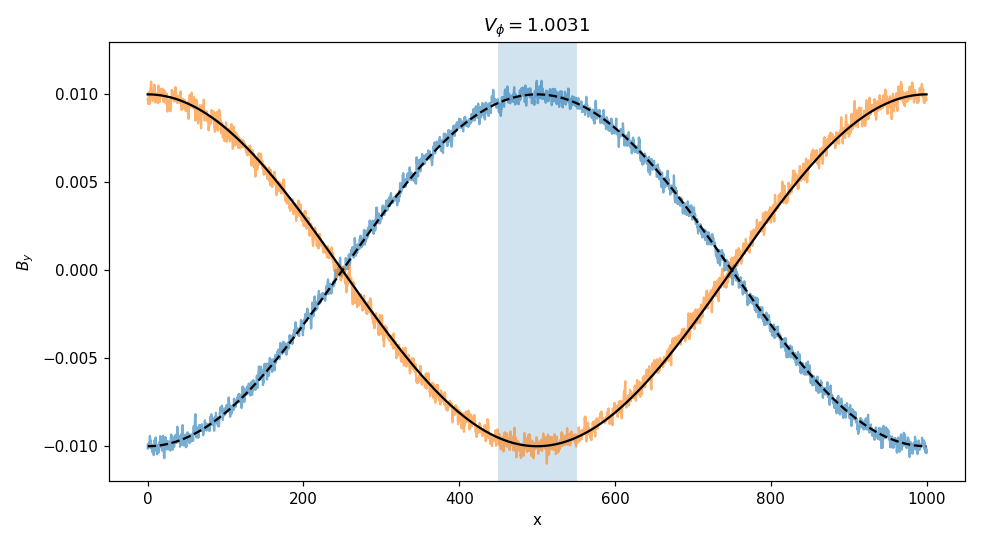

In [422]:

r11 = Run("../phare_jobs/tests/alfven_wave/run011")
t11 = get_times("../phare_jobs/tests/alfven_wave/run011/EM_B.h5")
fig,ax1 = plt.subplots(figsize=(9,5), nrows=1)



B = r11.GetB(t11[int(len(t11)/2)])
by, xby = finest_field(B, "By")
ax1.plot(xby, by, label="t = 500", alpha=0.6)

sorted_patches=sorted(B.patch_levels[1].patches, key=lambda p:p.box.lower[0])
x0 = sorted_patches[0].patch_datas["By"].x[0]
x1 = sorted_patches[-1].patch_datas["By"].x[-1]


B = r11.GetB(t11[-1])
by, xby = finest_field(B, "By")
ax1.plot(xby, by, label="t = 1000", alpha=0.6)
ax1.plot(xby, wave(xby, 0.01, 2*np.pi/1000., 2*np.pi/1000*500),
         color="k", ls="--", label="T=500 (theory)")


B = r11.GetB(t11[0])
by, xby = finest_field(B, "By")
ax1.plot(xby, by, label="t = 0", color="k")


ax1.set_xlabel("x")
ax1.set_ylabel(r"$B_y$")
#ax1.legend(ncol=4, loc="upper center")
ax1.set_ylim((-0.012, 0.013))
ax1.set_title(r"$V_\phi = {:6.4f}$".format(vphi11.mean()))

#ax2.plot(t11, vphi11, label=r"$\omega/k$")
#ax2.plot(t11, np.zeros_like(t11)+np.mean(vphi11), label="time average")
#ax2.legend(loc="upper right")
#ax2.set_title(r"wave speed $\omega/k$")
#ax2.set_xlabel(r"$t$")



ax1.axvspan(x0,x1, alpha=0.2)
fig.tight_layout()

fig.savefig("alfven_wave.png", dpi=200)

In [4]:

r13 = Run("/DATA/phare/pharebook_data/tests/alfven_wave/run013")
t13 = get_times("/DATA/phare/pharebook_data/tests/alfven_wave/run013/EM_B.h5")
fig,ax1 = plt.subplots(figsize=(9,5), nrows=1)



B = r13.GetB(t13[int(len(t13)/2)])
by, xby = finest_field(B, "By")
ax1.plot(xby, by, label="t = 500", alpha=0.6)

sorted_patches=sorted(B.patch_levels[1].patches, key=lambda p:p.box.lower[0])
x0 = sorted_patches[0].patch_datas["By"].x[0]
x1 = sorted_patches[-1].patch_datas["By"].x[-1]


B = r13.GetB(t13[-1])
by, xby = finest_field(B, "By")
ax1.plot(xby, by, label="t = 1000", alpha=0.6)
ax1.plot(xby, wave(xby, 0.01, 2*np.pi/1000., 2*np.pi/1000*500),
         color="k", ls="--", label="T=500 (theory)")


B = r13.GetB(t13[0])
by, xby = finest_field(B, "By")
ax1.plot(xby, by, label="t = 0", color="k")


ax1.set_xlabel("x")
ax1.set_ylabel(r"$B_y$")
ax1.legend(ncol=4, loc="upper center")
ax1.set_ylim((-0.012, 0.013))
ax1.set_title(r"$V_\phi = {:6.4f}$".format(vphi13.mean()))

#ax2.plot(t11, vphi11, label=r"$\omega/k$")
#ax2.plot(t11, np.zeros_like(t11)+np.mean(vphi11), label="time average")
#ax2.legend(loc="upper right")
#ax2.set_title(r"wave speed $\omega/k$")
#ax2.set_xlabel(r"$t$")



ax1.axvspan(x0,x1, alpha=0.2)
fig.tight_layout()

#fig.savefig("alfven_wave.png", dpi=200)

KeyboardInterrupt: 